In [4]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Carregar o conjunto de dados ERA5
# Usarei xr.open_dataset para ler o arquivo NetCDF antes de converter para DataFrame
data_path = '/content/era5_dataset.nc'
ds = xr.open_dataset(data_path)
df_era5_bruto = ds.to_dataframe().reset_index()

# 2. Selecionei as variáveis meteorológicas principais para o resumo
colunas_interesse = ['d2m', 't2m', 'sp', 'u100', 'v100', 'z']
# Filtrei apenas as colunas que existem no dataframe para evitar novos erros
colunas_presentes = [c for c in colunas_interesse if c in df_era5_bruto.columns]
tabela_estatistica = df_era5_bruto[colunas_presentes].describe()

print("Estatística Descritiva do ERA5:")
display(tabela_estatistica)

# 3. Verifiquei se existem dados nulos
print("\nVerificação de lacunas (dados faltantes):")
print(df_era5_bruto[colunas_presentes].isnull().sum())

Estatística Descritiva do ERA5:


,d2m,t2m,sp,u100,v100,z
count,76440.000000,76440.000000,76440.000000,76440.000000,76440.000000,76440.000000
mean,296.078247,301.155426,100755.234375,-6.222261,-2.893291,297.556793
std,1.463238,2.581281,416.105316,2.593695,2.243009,310.264496
min,285.433350,295.547241,99500.406250,-14.395645,-9.783936,-5.157715
25%,295.675964,299.752304,100422.937500,-8.154102,-4.573269,1.850098
50%,296.507141,300.437363,100846.875000,-6.066154,-3.066147,186.213379
75%,296.994995,301.536728,101089.750000,-4.247189,-1.388039,619.646973
max,298.763672,311.202148,101661.000000,3.073700,5.724304,933.174316



Verificação de lacunas (dados faltantes):
d2m     0
t2m     0
sp      0
u100    0
v100    0
z       0
dtype: int64


In [5]:
# Verificar o alcance temporal dos metadados
print(f"Início da série ERA5: {ds.valid_time.min().values}")
print(f"Fim da série ERA5:    {ds.valid_time.max().values}")

# Verificar a resolução temporal (deve ser 1 hora)
diff = ds.valid_time.diff('valid_time').values
print(f"Frequência dos dados: {np.unique(diff)}")

Início da série ERA5: 2021-09-01T00:00:00.000000000
Fim da série ERA5:    2021-11-30T23:00:00.000000000
Frequência dos dados: [3600000000000]


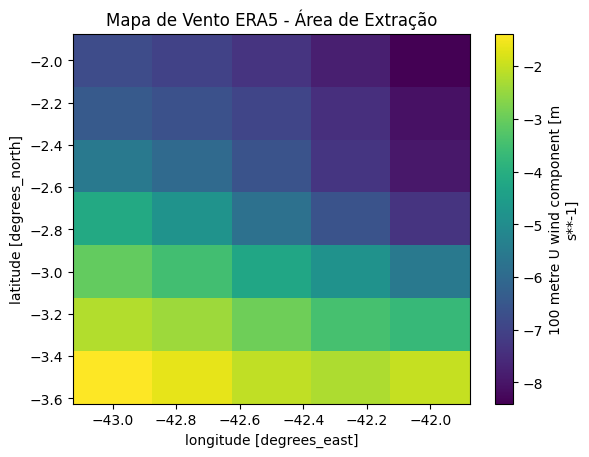

In [6]:
# 2. Visualizar a estrutura do "cubo de dados", duas estruturas de visualização:
#a estrutura geral do dataset e um mapa específico da variável de vento u100 para o primeiro tempo válido.

ds.u100.isel(valid_time=0).plot()
plt.title("Mapa de Vento ERA5 - Área de Extração")
plt.show()

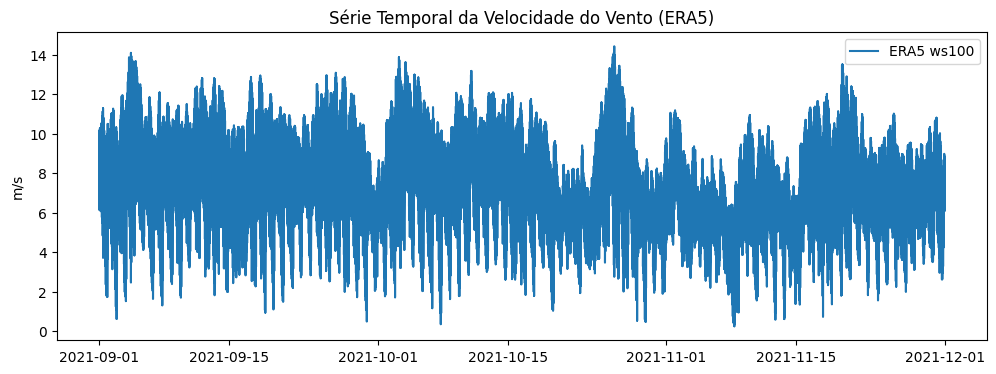

In [8]:
#Para gerar a velocidade escalar (ws100), calculei a
#magnitude vetorial combinando os componentes zonal (u100) e meridional (v100) fornecidos pela reanálise.

df_era5_bruto['ws100'] = np.sqrt(df_era5_bruto['u100']**2 + df_era5_bruto['v100']**2)

# Visualização 1: Série Temporal Completa
plt.figure(figsize=(12, 4))
plt.plot(df_era5_bruto['valid_time'], df_era5_bruto['ws100'], label='ERA5 ws100')
plt.title("Série Temporal da Velocidade do Vento (ERA5)")
plt.ylabel("m/s")
plt.legend()
plt.show()


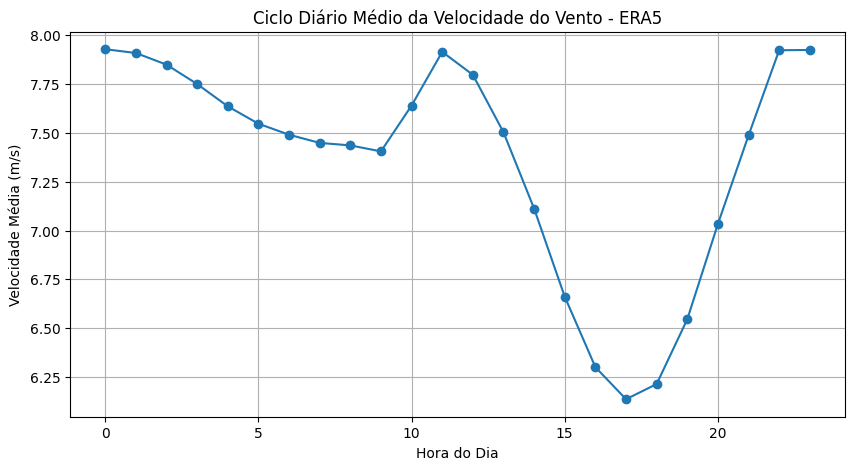

In [9]:
# Visualização 2: Ciclo Diário (Médias por Hora)
df_era5_bruto['hour'] = df_era5_bruto['valid_time'].dt.hour
diario_medio = df_era5_bruto.groupby('hour')['ws100'].mean()

plt.figure(figsize=(10, 5))
diario_medio.plot(kind='line', marker='o')
plt.title("Ciclo Diário Médio da Velocidade do Vento - ERA5")
plt.xlabel("Hora do Dia")
plt.ylabel("Velocidade Média (m/s)")
plt.grid(True)
plt.show()